# RQ4 — Actuation Repeatability

## Research question

> Is the commanded one-digit movement mechanically stable, and does repeating the same physical transition produce a reproducible acoustic pattern?

RQ4 is a validity check. A classifier can only learn a stable acoustic mechanism if the actuation itself is sufficiently repeatable. At the same time, very repeatable transition-specific sounds may become a shortcut: the model may learn *which physical transition occurred* rather than *whether the true gate was reached*.

### Data

- controlled `RQ1-4` dataset
- password: **3517**
- wheels: **W1, W2 and W4**
- direction: **CCW**
- loaded and unloaded states
- **600 one-digit movements**
- 10 physical transitions repeated 10 times within each wheel × loading condition

### Two checks

**Mechanical repeatability**

- final commanded step count
- position validity
- motion duration
- transition-level coefficient of variation (CV)

**Acoustic repeatability**

A leave-one-scan-out test is used separately for each wheel, loading state and recording channel.

For each held-out scan, the other nine scans define an acoustic centroid for each of the ten physical transitions. The held-out movement is then compared with:

1. the centroid of the **same transition**;
2. the centroids of the **other nine transitions**.

A distance ratio below 1 means that repetitions of the same transition are acoustically closer than unrelated transitions. As a second, more intuitive measure, the nearest centroid is used for 10-way transition identification; random accuracy is 10%.

The statistical test is performed at scan level, not candidate level.

## 1. Load the shared validity dataset

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

MYDRIVE = Path("/content/drive/MyDrive")
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (p / "00_RQ1-4_QC" / "RQ1-4_qc_manifest.csv").exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError("Could not locate Padlock_Reproduction_v1/results.")

QC_MANIFEST = (
    RESULTS_ROOT / "00_RQ1-4_QC" / "RQ1-4_qc_manifest.csv"
)
CACHE_PATH = (
    RESULTS_ROOT / "feature_cache" / "RQ1-4_interpretable_v1.npz"
)
RESULT_DIR = RESULTS_ROOT / "04_RQ4_Actuation_Repeatability"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(QC_MANIFEST)
cache = np.load(CACHE_PATH, allow_pickle=False)

X = cache["X"]
feature_names = cache["feature_names"].astype(str)
cache_run_ids = cache["run_ids"].astype(str)

if not np.array_equal(
    manifest["run_id"].astype(str).to_numpy(),
    cache_run_ids,
):
    raise RuntimeError("Cache run order does not match the QC manifest.")

feature_df = manifest.copy()
for j, name in enumerate(feature_names):
    feature_df[name] = X[:, j]

TARGET_FEATURES = [
    name for name in feature_names if name.startswith("target_")
]
REFERENCE_FEATURES = [
    name for name in feature_names if name.startswith("reference_")
]

assert len(feature_df) == 600
assert feature_df["scan_id"].nunique() == 60
assert feature_df["position_valid"].all()
assert feature_df["quality_valid"].all()

print("Runs:", len(feature_df))
print("Scans:", feature_df["scan_id"].nunique())
print("Target features:", len(TARGET_FEATURES))
print("Reference features:", len(REFERENCE_FEATURES))

Mounted at /content/drive
Runs: 600
Scans: 60
Target features: 13
Reference features: 13


## 2. Mechanical repeatability

In [2]:
motion_by_transition = (
    feature_df
    .groupby(["wheel", "tension_state", "transition"])["motion_duration_s"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

motion_by_transition["cv_pct"] = (
    100 * motion_by_transition["std"] / motion_by_transition["mean"]
)

motion_by_transition["range_ms"] = (
    1000 * (
        motion_by_transition["max"] - motion_by_transition["min"]
    )
)

motion_summary = (
    motion_by_transition
    .groupby(["wheel", "tension_state"])
    .agg(
        transitions=("transition", "count"),
        mean_duration_s=("mean", "mean"),
        median_cv_pct=("cv_pct", "median"),
        max_cv_pct=("cv_pct", "max"),
        median_range_ms=("range_ms", "median"),
        max_range_ms=("range_ms", "max"),
    )
    .reset_index()
)

motion_summary.to_csv(
    RESULT_DIR / "RQ4_motion_repeatability.csv",
    index=False,
)
motion_by_transition.to_csv(
    RESULT_DIR / "RQ4_motion_by_transition.csv",
    index=False,
)

display(motion_summary.round(4))

print("Final-step counts:", feature_df["final_step"].value_counts().to_dict())
print("Invalid positions:", int((~feature_df["position_valid"]).sum()))

,wheel,tension_state,transitions,mean_duration_s,median_cv_pct,max_cv_pct,median_range_ms,max_range_ms
0,1,LOADED,10,0.2748,0.1922,0.2355,1.4955,2.023
1,1,UNLOADED,10,0.2747,0.2066,0.2410,1.7525,1.948
2,2,LOADED,10,0.2747,0.1760,0.2578,1.6545,2.161
3,2,UNLOADED,10,0.2747,0.1964,0.2152,1.6045,2.007
4,4,LOADED,10,0.2747,0.1855,0.2181,1.4540,1.743
5,4,UNLOADED,10,0.2747,0.1858,0.2240,1.3990,1.765


Final-step counts: {171: 600}
Invalid positions: 0


## 3. Acoustic transition repeatability

The feature scaling is fitted on the nine training scans only. This prevents the held-out scan from influencing the transition centroids or the normalization.

In [3]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


def evaluate_repeatability(wheel, state, channel, features):
    data = feature_df[
        (feature_df["wheel"] == wheel)
        & (feature_df["tension_state"] == state)
    ].copy()

    fold_rows = []
    candidate_rows = []

    for test_scan in sorted(data["scan_id"].unique()):
        train = data[data["scan_id"] != test_scan].copy()
        test = data[data["scan_id"] == test_scan].copy()

        X_train = train[features].to_numpy(dtype=float)

        median = np.median(X_train, axis=0)
        mad = np.median(np.abs(X_train - median), axis=0)
        scale = 1.4826 * mad

        std = np.std(X_train, axis=0, ddof=1)
        scale = np.where(scale > 1e-12, scale, std)
        scale = np.where(scale > 1e-12, scale, 1.0)

        train_scaled = train.copy()
        train_scaled[features] = (X_train - median) / scale

        test_X = (
            test[features].to_numpy(dtype=float) - median
        ) / scale

        centroids = {}

        for transition in sorted(train_scaled["transition"].unique()):
            centroids[transition] = (
                train_scaled.loc[
                    train_scaled["transition"] == transition,
                    features,
                ]
                .to_numpy(dtype=float)
                .mean(axis=0)
            )

        same_distances = []
        other_distances = []
        correct = []

        for row, x in zip(test.itertuples(index=False), test_X):
            distances = {
                transition: np.linalg.norm(x - centroid)
                for transition, centroid in centroids.items()
            }

            same = distances[row.transition]

            other = np.mean([
                value
                for transition, value in distances.items()
                if transition != row.transition
            ])

            predicted = min(
                distances,
                key=distances.get,
            )

            is_correct = int(
                predicted == row.transition
            )

            same_distances.append(same)
            other_distances.append(other)
            correct.append(is_correct)

            candidate_rows.append({
                "wheel": wheel,
                "state": state,
                "channel": channel,
                "test_scan": int(test_scan),
                "transition": row.transition,
                "same_distance": same,
                "other_distance": other,
                "distance_ratio": same / other,
                "nearest_correct": is_correct,
            })

        fold_rows.append({
            "wheel": wheel,
            "state": state,
            "channel": channel,
            "test_scan": int(test_scan),
            "same_transition_distance": np.mean(same_distances),
            "other_transition_distance": np.mean(other_distances),
            "distance_ratio": (
                np.mean(same_distances)
                / np.mean(other_distances)
            ),
            "nearest_centroid_accuracy": np.mean(correct),
        })

    return (
        pd.DataFrame(fold_rows),
        pd.DataFrame(candidate_rows),
    )


fold_tables = []
candidate_tables = []

for wheel in [1, 2, 4]:
    for state in ["LOADED", "UNLOADED"]:
        for channel, features in [
            ("Target", TARGET_FEATURES),
            ("Reference", REFERENCE_FEATURES),
        ]:
            folds, candidates = evaluate_repeatability(
                wheel,
                state,
                channel,
                features,
            )
            fold_tables.append(folds)
            candidate_tables.append(candidates)

repeatability = pd.concat(
    fold_tables,
    ignore_index=True,
)
candidate_predictions = pd.concat(
    candidate_tables,
    ignore_index=True,
)

repeatability.to_csv(
    RESULT_DIR / "RQ4_acoustic_repeatability_folds.csv",
    index=False,
)
candidate_predictions.to_csv(
    RESULT_DIR / "RQ4_transition_predictions.csv",
    index=False,
)

## 4. Scan-level statistical summary

In [4]:
def bootstrap_mean_ci(values, seed, n_boot=20000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)

    idx = rng.integers(
        0,
        len(values),
        size=(n_boot, len(values)),
    )

    boot = values[idx].mean(axis=1)

    return np.quantile(
        boot,
        [0.025, 0.975],
    )


summary_rows = []
seed = 20260819

for (
    wheel,
    state,
    channel,
), group in repeatability.groupby(
    ["wheel", "state", "channel"]
):
    stat, p_value = wilcoxon(
        group["same_transition_distance"],
        group["other_transition_distance"],
        alternative="less",
        method="auto",
    )

    ratio_ci = bootstrap_mean_ci(
        group["distance_ratio"].to_numpy(),
        seed=seed,
    )

    accuracy_ci = bootstrap_mean_ci(
        group["nearest_centroid_accuracy"].to_numpy(),
        seed=seed + 100,
    )

    seed += 1

    summary_rows.append({
        "wheel": wheel,
        "state": state,
        "channel": channel,
        "n_scans": len(group),
        "mean_same_distance": group["same_transition_distance"].mean(),
        "mean_other_distance": group["other_transition_distance"].mean(),
        "mean_distance_ratio": group["distance_ratio"].mean(),
        "ratio_ci_low": ratio_ci[0],
        "ratio_ci_high": ratio_ci[1],
        "nearest_centroid_accuracy": group["nearest_centroid_accuracy"].mean(),
        "accuracy_ci_low": accuracy_ci[0],
        "accuracy_ci_high": accuracy_ci[1],
        "p_raw": p_value,
    })

repeatability_summary = pd.DataFrame(summary_rows)

repeatability_summary["p_holm"] = multipletests(
    repeatability_summary["p_raw"],
    method="holm",
)[1]

repeatability_summary.to_csv(
    RESULT_DIR / "RQ4_acoustic_repeatability_summary.csv",
    index=False,
)

display(
    repeatability_summary[
        [
            "wheel",
            "state",
            "channel",
            "mean_distance_ratio",
            "nearest_centroid_accuracy",
            "p_holm",
        ]
    ].round(3)
)

,wheel,state,channel,mean_distance_ratio,nearest_centroid_accuracy,p_holm
0,1,LOADED,Reference,0.958,0.11,0.158
1,1,LOADED,Target,0.791,0.15,0.012
2,1,UNLOADED,Reference,1.051,0.06,0.998
3,1,UNLOADED,Target,0.975,0.16,0.432
4,2,LOADED,Reference,0.812,0.27,0.012
5,2,LOADED,Target,0.724,0.25,0.012
6,2,UNLOADED,Reference,0.811,0.27,0.012
7,2,UNLOADED,Target,0.750,0.34,0.012
8,4,LOADED,Reference,0.697,0.30,0.012
9,4,LOADED,Target,0.621,0.42,0.012


## 5. Main figures

The three figures show mechanical stability, acoustic same-transition clustering, and practical 10-way transition identification. Figure titles are left to the report caption.

In [5]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#7898AF"
LIGHT_BLUE = "#BCD0DE"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )


condition_order = [
    (1, "LOADED"),
    (1, "UNLOADED"),
    (2, "LOADED"),
    (2, "UNLOADED"),
    (4, "LOADED"),
    (4, "UNLOADED"),
]

condition_labels = [
    "W1 Loaded",
    "W1 Unloaded",
    "W2 Loaded",
    "W2 Unloaded",
    "W4 Loaded",
    "W4 Unloaded",
]

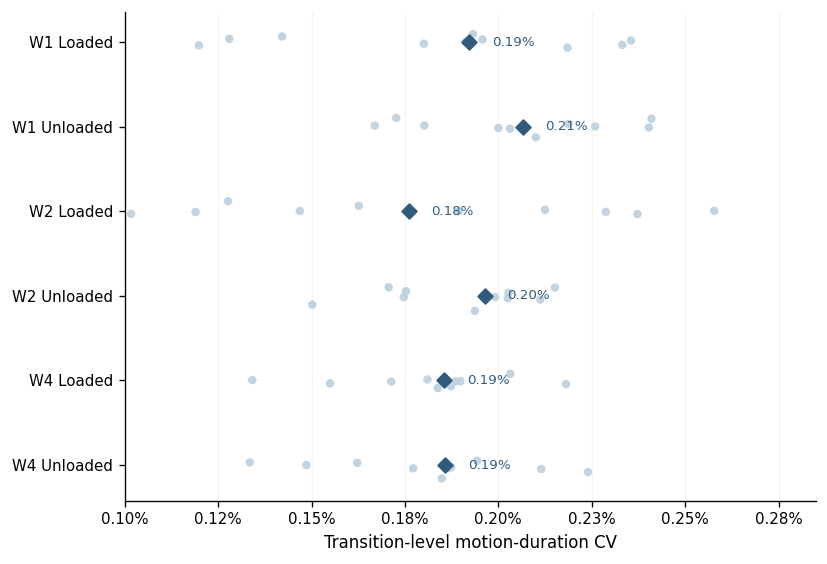

In [6]:
# Figure 1 — transition-level motion-duration CV

fig, ax = plt.subplots(
    figsize=(7.0, 4.8)
)

rng = np.random.default_rng(
    20260819
)

for yi, (wheel, state) in enumerate(
    condition_order
):
    values = motion_by_transition.loc[
        (motion_by_transition["wheel"] == wheel)
        & (
            motion_by_transition["tension_state"]
            == state
        ),
        "cv_pct",
    ].to_numpy()

    y = rng.normal(
        yi,
        0.055,
        size=len(values),
    )

    ax.scatter(
        values,
        y,
        s=26,
        color=LIGHT_BLUE,
        edgecolor="none",
        alpha=0.9,
        zorder=2,
    )

    median = np.median(values)

    ax.scatter(
        [median],
        [yi],
        marker="D",
        s=40,
        color=DARK_BLUE,
        zorder=3,
    )

    ax.text(
        median + 0.006,
        yi,
        f"{median:.2f}%",
        va="center",
        fontsize=8,
        color=DARK_BLUE,
    )

ax.set_yticks(
    np.arange(
        len(condition_labels)
    )
)

ax.set_yticklabels(
    condition_labels
)

ax.invert_yaxis()

ax.set_xlabel(
    "Transition-level motion-duration CV"
)

ax.set_xlim(
    0.10,
    0.285,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.2f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ4_Fig1_motion_timing_repeatability",
)

plt.show()

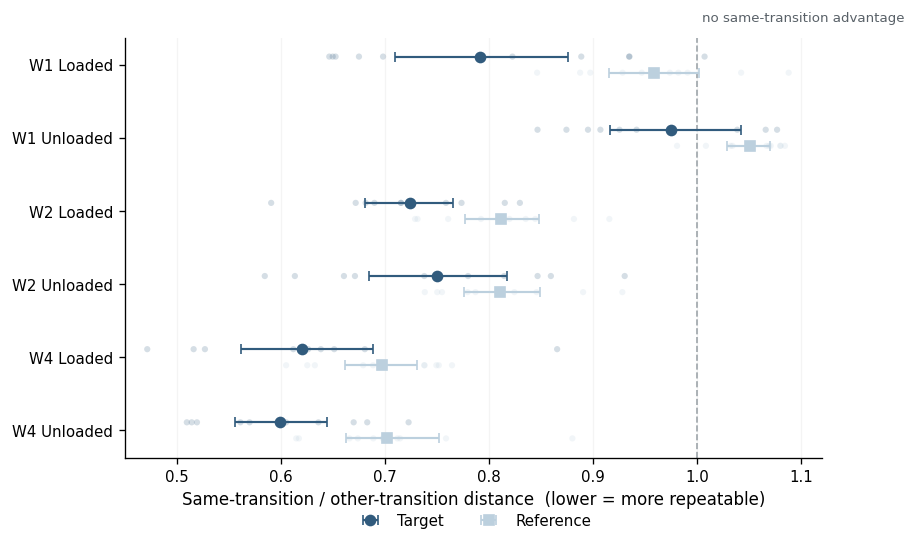

In [7]:
# Figure 2 — same-transition / other-transition distance

fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)

y_base = np.arange(
    len(condition_order)
)

offsets = {
    "Target": -0.11,
    "Reference": 0.11,
}

markers = {
    "Target": "o",
    "Reference": "s",
}

colors = {
    "Target": DARK_BLUE,
    "Reference": LIGHT_BLUE,
}

for channel in [
    "Target",
    "Reference",
]:
    for i, (wheel, state) in enumerate(
        condition_order
    ):
        group = repeatability[
            (repeatability["wheel"] == wheel)
            & (repeatability["state"] == state)
            & (repeatability["channel"] == channel)
        ]

        summary = repeatability_summary[
            (repeatability_summary["wheel"] == wheel)
            & (repeatability_summary["state"] == state)
            & (repeatability_summary["channel"] == channel)
        ].iloc[0]

        y = (
            y_base[i]
            + offsets[channel]
        )

        ax.scatter(
            group["distance_ratio"],
            np.full(len(group), y),
            s=14,
            color=colors[channel],
            alpha=0.20,
            edgecolor="none",
            zorder=1,
        )

        mean = summary[
            "mean_distance_ratio"
        ]
        lo = summary[
            "ratio_ci_low"
        ]
        hi = summary[
            "ratio_ci_high"
        ]

        ax.errorbar(
            mean,
            y,
            xerr=[
                [mean - lo],
                [hi - mean],
            ],
            fmt=markers[channel],
            markersize=6,
            capsize=3,
            linewidth=1.3,
            color=colors[channel],
            label=(
                channel
                if i == 0
                else None
            ),
            zorder=3,
        )

ax.axvline(
    1.0,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.text(
    1.005,
    -0.55,
    "no same-transition advantage",
    fontsize=8,
    color=DARK_GREY,
    va="bottom",
)

ax.set_yticks(
    y_base
)

ax.set_yticklabels(
    condition_labels
)

ax.invert_yaxis()

ax.set_xlabel(
    "Same-transition / other-transition distance  (lower = more repeatable)"
)

ax.set_xlim(
    0.45,
    1.12,
)

ax.grid(
    axis="x",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
)

fig.subplots_adjust(
    bottom=0.18
)

save_figure(
    fig,
    "RQ4_Fig2_acoustic_distance_ratio",
)

plt.show()

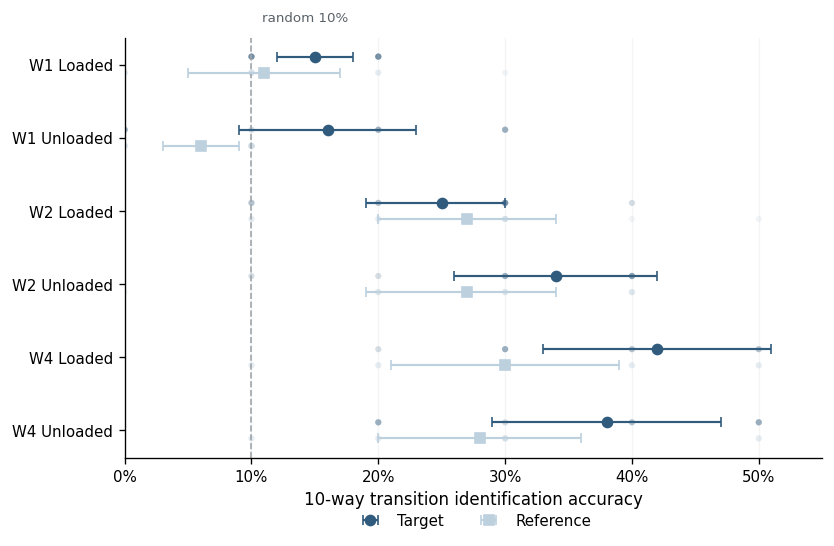

In [8]:
# Figure 3 — held-out 10-way transition identification

fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)

for channel in [
    "Target",
    "Reference",
]:
    for i, (wheel, state) in enumerate(
        condition_order
    ):
        group = repeatability[
            (repeatability["wheel"] == wheel)
            & (repeatability["state"] == state)
            & (repeatability["channel"] == channel)
        ]

        summary = repeatability_summary[
            (repeatability_summary["wheel"] == wheel)
            & (repeatability_summary["state"] == state)
            & (repeatability_summary["channel"] == channel)
        ].iloc[0]

        y = (
            y_base[i]
            + offsets[channel]
        )

        mean = (
            100
            * summary[
                "nearest_centroid_accuracy"
            ]
        )

        lo = (
            100
            * summary[
                "accuracy_ci_low"
            ]
        )

        hi = (
            100
            * summary[
                "accuracy_ci_high"
            ]
        )

        ax.scatter(
            100
            * group[
                "nearest_centroid_accuracy"
            ],
            np.full(
                len(group),
                y,
            ),
            s=14,
            color=colors[channel],
            alpha=0.20,
            edgecolor="none",
            zorder=1,
        )

        ax.errorbar(
            mean,
            y,
            xerr=[
                [mean - lo],
                [hi - mean],
            ],
            fmt=markers[channel],
            markersize=6,
            capsize=3,
            linewidth=1.3,
            color=colors[channel],
            label=(
                channel
                if i == 0
                else None
            ),
            zorder=3,
        )

ax.axvline(
    10,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.text(
    10.8,
    -0.55,
    "random 10%",
    fontsize=8,
    color=DARK_GREY,
    va="bottom",
)

ax.set_yticks(
    y_base
)

ax.set_yticklabels(
    condition_labels
)

ax.invert_yaxis()

ax.set_xlabel(
    "10-way transition identification accuracy"
)

ax.set_xlim(
    0,
    55,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
)

fig.subplots_adjust(
    bottom=0.18
)

save_figure(
    fig,
    "RQ4_Fig3_transition_identity_accuracy",
)

plt.show()

## 6. Tables

In [9]:
table1 = motion_summary.copy()

table1["Condition"] = (
    "W"
    + table1["wheel"].astype(str)
    + " "
    + table1["tension_state"].str.title()
)

table1["Mean duration (ms)"] = (
    1000 * table1["mean_duration_s"]
).map(
    lambda x: f"{x:.2f}"
)

table1["Median CV"] = (
    table1["median_cv_pct"]
).map(
    lambda x: f"{x:.3f}%"
)

table1["Max CV"] = (
    table1["max_cv_pct"]
).map(
    lambda x: f"{x:.3f}%"
)

table1["Max range (ms)"] = (
    table1["max_range_ms"]
).map(
    lambda x: f"{x:.3f}"
)

table1 = table1[
    [
        "Condition",
        "Mean duration (ms)",
        "Median CV",
        "Max CV",
        "Max range (ms)",
    ]
]

table1.to_csv(
    RESULT_DIR / "RQ4_Table1_mechanical_repeatability.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ4_Table1_mechanical_repeatability.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )

display(table1)


table2 = repeatability_summary.copy()

table2["Condition"] = (
    "W"
    + table2["wheel"].astype(str)
    + " "
    + table2["state"].str.title()
)

table2["Distance ratio"] = (
    table2["mean_distance_ratio"]
).map(
    lambda x: f"{x:.3f}"
)

table2["Transition accuracy"] = (
    100
    * table2["nearest_centroid_accuracy"]
).map(
    lambda x: f"{x:.0f}%"
)

table2["Holm p"] = (
    table2["p_holm"]
).map(
    lambda x: (
        "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

table2 = table2[
    [
        "Condition",
        "channel",
        "Distance ratio",
        "Transition accuracy",
        "Holm p",
    ]
].rename(
    columns={
        "channel": "Channel",
    }
)

table2.to_csv(
    RESULT_DIR / "RQ4_Table2_acoustic_repeatability.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ4_Table2_acoustic_repeatability.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(table2)

,Condition,Mean duration (ms),Median CV,Max CV,Max range (ms)
0,W1 Loaded,274.76,0.192%,0.236%,2.023
1,W1 Unloaded,274.73,0.207%,0.241%,1.948
2,W2 Loaded,274.72,0.176%,0.258%,2.161
3,W2 Unloaded,274.70,0.196%,0.215%,2.007
4,W4 Loaded,274.73,0.186%,0.218%,1.743
5,W4 Unloaded,274.73,0.186%,0.224%,1.765


,Condition,Channel,Distance ratio,Transition accuracy,Holm p
0,W1 Loaded,Reference,0.958,11%,0.158
1,W1 Loaded,Target,0.791,15%,0.012
2,W1 Unloaded,Reference,1.051,6%,0.998
3,W1 Unloaded,Target,0.975,16%,0.432
4,W2 Loaded,Reference,0.812,27%,0.012
5,W2 Loaded,Target,0.724,25%,0.012
6,W2 Unloaded,Reference,0.811,27%,0.012
7,W2 Unloaded,Target,0.750,34%,0.012
8,W4 Loaded,Reference,0.697,30%,0.012
9,W4 Loaded,Target,0.621,42%,0.012


## 7. Result record

In [10]:
rq4_conclusion = {
    "research_question": (
        "Is the commanded one-digit actuation mechanically stable, "
        "and are repeated executions of the same physical transition acoustically repeatable?"
    ),
    "n_runs": 600,
    "final_step_all_runs": 171,
    "invalid_positions": int(
        (~feature_df["position_valid"]).sum()
    ),
    "mechanical_result": {
        "median_cv_range_pct": [
            float(
                motion_summary["median_cv_pct"].min()
            ),
            float(
                motion_summary["median_cv_pct"].max()
            ),
        ],
        "maximum_transition_cv_pct": float(
            motion_summary["max_cv_pct"].max()
        ),
        "maximum_transition_range_ms": float(
            motion_summary["max_range_ms"].max()
        ),
    },
    "acoustic_result": (
        repeatability_summary[
            [
                "wheel",
                "state",
                "channel",
                "mean_distance_ratio",
                "nearest_centroid_accuracy",
                "p_holm",
            ]
        ].to_dict(
            orient="records"
        )
    ),
    "interpretation": (
        "The one-digit motion command is mechanically highly repeatable: "
        "all 600 movements completed 171 steps with no invalid positions, "
        "and transition-level motion-duration variation remained below 0.26% CV. "
        "Acoustic repeatability is also present, but it is wheel dependent. "
        "W2 and W4 show consistent same-transition clustering in both loading states "
        "and both recording channels, whereas W1 is substantially weaker and becomes "
        "reliably separable only for the loaded target channel."
    ),
    "limitation": (
        "Repeatable transition identity is not the same as a true-gate mechanism. "
        "Stable transition-specific fingerprints can become a shortcut for a classifier."
    ),
    "next_step": (
        "RQ5 therefore tests whether contextual transition identity, rather than gate physics, "
        "can explain recognition performance."
    ),
}

with open(
    RESULT_DIR / "RQ4_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        rq4_conclusion,
        f,
        indent=2,
    )

run_info = {
    "notebook": "04_RQ4_Actuation_Repeatability.ipynb",
    "dataset": "RQ1-4 controlled validity dataset",
    "password": "3517",
    "direction": "CCW",
    "wheels": [1, 2, 4],
    "states": [
        "LOADED",
        "UNLOADED",
    ],
    "n_runs": 600,
    "feature_count_per_channel": 13,
    "acoustic_validation": (
        "Leave-one-scan-out transition centroid classification; "
        "training-fold median/MAD scaling only."
    ),
    "statistical_test": (
        "One-sided paired Wilcoxon across 10 held-out scans: "
        "same-transition distance < mean other-transition distance; "
        "Holm correction across 12 wheel/state/channel tests."
    ),
}

with open(
    RESULT_DIR / "RQ4_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(json.dumps(rq4_conclusion, indent=2))

print("\nSaved outputs:")
for path in sorted(
    RESULT_DIR.glob("RQ4_*")
):
    print(" -", path.name)

{
  "research_question": "Is the commanded one-digit actuation mechanically stable, and are repeated executions of the same physical transition acoustically repeatable?",
  "n_runs": 600,
  "final_step_all_runs": 171,
  "invalid_positions": 0,
  "mechanical_result": {
    "median_cv_range_pct": [
      0.17599029346747908,
      0.20656882095677392
    ],
    "maximum_transition_cv_pct": 0.25776337409865296,
    "maximum_transition_range_ms": 2.161000000000024
  },
  "acoustic_result": [
    {
      "wheel": 1,
      "state": "LOADED",
      "channel": "Reference",
      "mean_distance_ratio": 0.9582096987654166,
      "nearest_centroid_accuracy": 0.11000000000000001,
      "p_holm": 0.158203125
    },
    {
      "wheel": 1,
      "state": "LOADED",
      "channel": "Target",
      "mean_distance_ratio": 0.7909840923685584,
      "nearest_centroid_accuracy": 0.15000000000000002,
      "p_holm": 0.01171875
    },
    {
      "wheel": 1,
      "state": "UNLOADED",
      "channel": "Refe